In [106]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

from PIL import Image
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import time
from tqdm import tqdm

import os
import shutil
from pathlib import Path

# Skin Diseases Classifier
* Kaggle: https://www.kaggle.com/datasets/sponishflea/classification-of-skin-diseases?resource=download

In [107]:
root_dir = "./data/skin_diseases"
from_dir = os.path.join(root_dir, "train")
to_dir = os.path.join(root_dir, "skin_disease")

In [108]:
# class 폴더명 -> 정수 라벨 매핑
class_names = sorted([d.name for d in Path(from_dir).iterdir() if d.is_dir()])
class_to_idx = {c:i for i,c in enumerate(class_names)}

# 전부 .jpg 인지 확인 - .jpg 아닌 것들 출력
for path in Path(from_dir).rglob("*"):
    if path.is_file() and path.suffix.lower() != ".jpg":
        print(path.suffix)
        
# 또는
unique_ext = {p.suffix.lower() for p in Path(from_dir).rglob("*") if p.is_file()}
print(unique_ext)

{'.jpg'}


In [138]:
class ourDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        # 각 이미지가 들어있는 디렉토리를 리스트에 추가.
        img_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
        self.base_dir = base_dir
        self.img_paths = []
        self.labels = []

        # 각 클래스와 인덱스가 맵핑된 딕셔너리 생성.
        self.cls_to_idx = {cls: i for i, cls in enumerate(img_dirs)}
        self.idx_to_cls = {i: cls for cls, i in self.cls_to_idx.items()}
        
        exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

        # 이미지 경로와 레이블을 리스트에 추가.
        for img_dir in img_dirs:
            dir_path = os.path.join(base_dir, img_dir)
            img_names = [
                os.path.join(dir_path, f)
                for f in os.listdir(dir_path)
                if f.lower().endswith(exts)   # ✅ 대소문자/확장자 커버
            ]
            self.img_paths.extend(img_names)
            self.labels.extend([self.cls_to_idx[img_dir]] * len(img_names))

        self.transform = transform


    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')

        # Image Augmentation 수행 ( 수행을 하지 않고 데이터로더로 데이터셋 확인시 배치사이즈는 1로 해야 한다. )
        if self.transform:
            image = self.transform(image)
        else: image = transforms.ToTensor()(image)

        label = self.labels[idx]

        return image, label


    def __len__(self):
        return len(self.img_paths)


In [110]:
# 데이터 분포 확인
def print_cls_dist(dataset):
    if isinstance(dataset, Subset):
        if isinstance(dataset.dataset, Subset):
            # Subset 객체에서 오리지널 dataset를 접근할 수 있다.
            # Subset 객체의 indices를 이용해 labels를 추출한다.
            labels = [dataset.dataset.dataset[dataset.dataset.indices[i]][1] for i in dataset.indices]
            idx_to_cls = dataset.dataset.dataset.idx_to_cls
        else:
            labels = [dataset.dataset.labels[i] for i in dataset.indices]
            idx_to_cls = dataset.dataset.idx_to_cls
    else:
        labels = dataset.labels
        idx_to_cls = dataset.idx_to_cls

    # 클래스명과 이미지 개수 출력 ( np로 순서에 대한 정보를 유지할 수 있음 )
    unique, counts = np.unique(labels, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"{cls}.{idx_to_cls[cls]:18}: {count}")

In [111]:
# 인스턴스
dataset = ourDataset(base_dir=from_dir)
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True)

# 데이터셋의 크기 확인
print('Size of Dataset:', len(dataset))
print('Size of Dataloader:', len(dataloader))

# 클래스 개수
num_classes = len(dataset.cls_to_idx)
print('Number of Classes:', num_classes)

# 클래스별 데이터 분포
print_cls_dist(dataset)

Size of Dataset: 1494
Size of Dataloader: 1494
Number of Classes: 5
0.acne              : 300
1.eksim             : 297
2.herpes            : 300
3.panu              : 297
4.rosacea           : 300


In [112]:
def get_base_and_indices(ds):
    indices = None
    
    while isinstance(ds, Subset):
        if indices is None:
            indices = list(ds.indices)
        else:
            indices = [ds.indices[i] for i in indices]
        ds = ds.dataset

    base = ds
    
    if indices is None:
        indices = list(range(len(base)))

    return base, indices

In [113]:
#  imbalanced 데이터셋 해결책 3가지:
# 1. Oversampling
# 2. Undersampling
# 3. Class Weighting


## Undersampling

def undersample_dataset(ds, random_seed=42):
    np.random.seed(random_seed)

    base, base_indices = get_base_and_indices(ds)

    # 라벨 추출
    if hasattr(base, "targets"):
        y = np.array([base.targets[i] for i in base_indices])
    elif hasattr(base, "labels"):
        y = np.array([base.labels[i] for i in base_indices])
    else:
        raise AttributeError("base dataset에 targets/labels가 없음")

    unique, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    print("min_count:", int(min_count))

    keep = []
    for c in unique:
        cls_pos = np.where(y == c)[0]
        chosen_pos = np.random.choice(cls_pos, size=min_count, replace=False)
        keep.extend([base_indices[p] for p in chosen_pos])

    return Subset(base, keep)

# 인스턴스
dataset = ourDataset(base_dir = from_dir)
dataset = undersample_dataset(dataset)

# 클래스별 데이터 분포
print_cls_dist(dataset)

# dataset 형태
print(type(dataset))

min_count: 297
0.acne              : 297
1.eksim             : 297
2.herpes            : 297
3.panu              : 297
4.rosacea           : 297
<class 'torch.utils.data.dataset.Subset'>


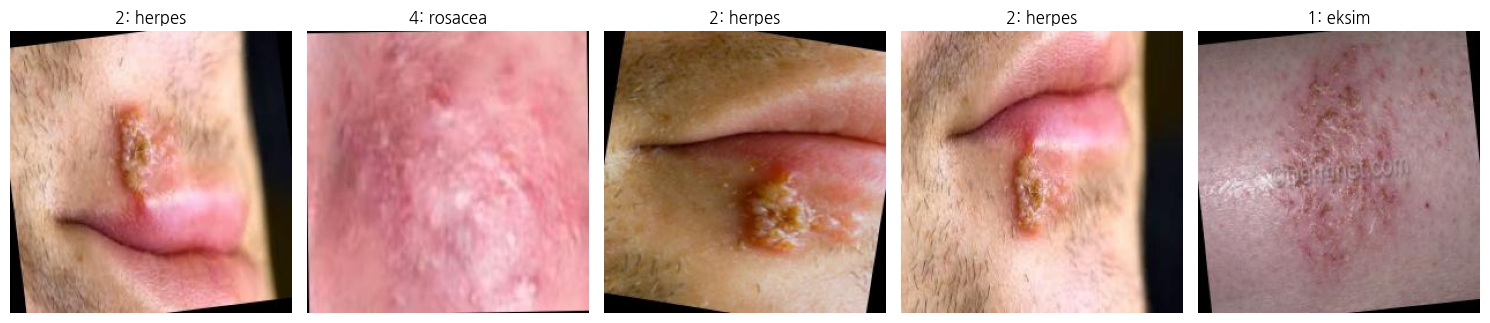

In [114]:
# 데이터 시각화

def show_images(dataset, num_images=5):

    # 시각화를 위해 데이터로더를 이터레이터로 변환해준다.
    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    iter_dataloader = iter(loader)

    plt.figure(figsize=(num_images*3, num_images*1))
    for i, (images, labels) in zip(range(num_images), iter_dataloader):
        #print('Image shape:', images.shape)
        plt.subplot(1, num_images, i + 1)
        # 스칼라의 데이터를 불러올 때 item() 메서드를 사용한다.
        label_idx = labels.item()
        plt.title(f"{label_idx}: {dataset.idx_to_cls[label_idx]}")
        # plt의 imshow 함수는 이미지의 shape이 [height, width, channel]로 되어있어야 하므로 permute으로 변환해준다.
        plt.imshow(images[0].permute(1, 2, 0))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# undersampling된 데이터셋은 Subset이기 때문에 idx_to_cls attribute을 강제로 붙임
if isinstance(dataset, Subset):
    dataset.idx_to_cls = dataset.dataset.idx_to_cls

show_images(dataset)

In [115]:
# 입력데이터셋의 정보 확인

iter_dataloader = iter(dataloader)
hw_sizes = []

for image, _ in iter_dataloader:
    hw_sizes.append(image.shape[2:])

hw_sizes = np.array(hw_sizes)

# 전부 244임을 확인
print('min HxW:', hw_sizes.min(axis=0))
print('max HxW:', hw_sizes.max(axis=0))
print('mean HxW:', hw_sizes.mean(axis=0))

min HxW: [244 244]
max HxW: [244 244]
mean HxW: [244. 244.]


In [116]:
# 현재 데이터셋에 맞는 정규화를 위한 Mean, Std을 계산하기. ( 데이터가 적어서 중요한 부분은 아닐 수 있음. )

def calculate_mean_std(dataset):
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    loader = iter(dataloader)

    mean = 0.0
    std = 0.0
    dataset_size = len(dataset)  # 전체 데이터셋 크기.
    for images, _ in loader:
        batch_samples = images.size(0)  # 배치 크기
        images = images.view(batch_samples, images.size(1), -1)  # 이미지 펼치기
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
    mean /= dataset_size
    std /= dataset_size
    return mean, std

mean, std = calculate_mean_std(dataset)
print(f'데이터셋 평균: {mean}')
print(f'데이터셋 Std dev.: {std}')
print('이미지넷 평균', [0.485, 0.456, 0.406])
print('이미지넷 Std dev.', [0.229, 0.224, 0.225])

데이터셋 평균: tensor([0.6612, 0.4816, 0.4278])
데이터셋 Std dev.: tensor([0.1898, 0.1645, 0.1566])
이미지넷 평균 [0.485, 0.456, 0.406]
이미지넷 Std dev. [0.229, 0.224, 0.225]


In [117]:
transform = {
    "train": transforms.Compose([
        transforms.Resize((244,244)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomAffine(degrees=25),
        #transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.6609, 0.4816, 0.4278],[0.1900, 0.1647, 0.1567])
    ]),
    "val": transforms.Compose([
        transforms.Resize((244,244)),
        transforms.ToTensor(),
        transforms.Normalize([0.6609, 0.4816, 0.4278],[0.1900, 0.1647, 0.1567])
    ])
}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..0.8236297].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..2.3251874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..2.8757586].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..3.1009922].


min_count: 297


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..1.8141602].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..2.43323].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..2.0284536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..2.2427468].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..2.2501097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.478421..1.6712979].


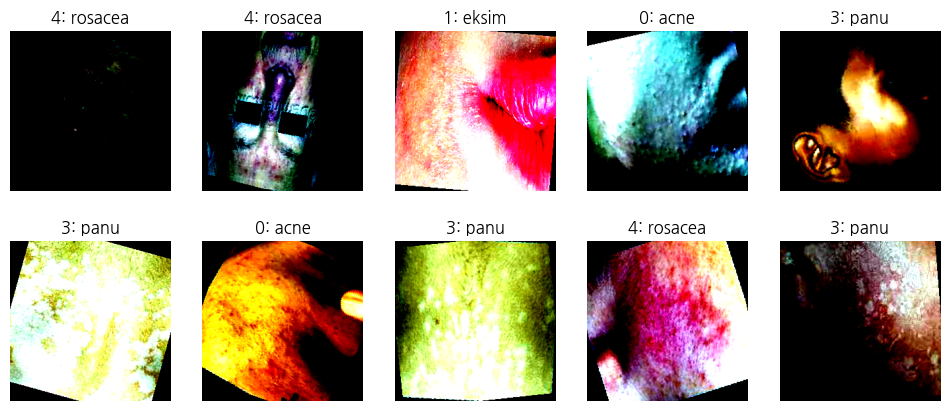

In [118]:
# 증강된 데이터셋 확인
dataset = ourDataset(base_dir=from_dir, transform = transform['train'])

# undersampling
new_dataset = undersample_dataset(dataset)
dataloader = DataLoader(new_dataset, batch_size=1, shuffle=True)

# attribute 추가
if isinstance(new_dataset, Subset):
    new_dataset.idx_to_cls = new_dataset.dataset.idx_to_cls


iter_dataloader = iter(dataloader)

# 이미지 시각화
plt.figure(figsize=(12, 5))
for i, (augmented_image, label) in zip(range(10), iter_dataloader):
    plt.subplot(2, 5, i + 1)
    label_idx = label.item()
    plt.title(f"{label_idx}: {dataset.idx_to_cls[label_idx]}")
    plt.imshow(augmented_image[0].permute(1, 2, 0))
    plt.axis('off')
plt.show()

In [119]:
# 학습 데이터셋과 검증 데이터셋 나누기.
# 클래스별 고른 분포를 위해 sklearn의 split을 사용함 : pytorch의 random split은 고른 분포를 고려하지 않음

def stratified_split_dataset(dataset, val_split_ratio=0.2, random_seed=42):
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    # 1) dataset이 Subset인지 확인
    if isinstance(dataset, Subset):
        base_dataset = dataset.dataset              # 원본 (ex. ImageFolder)
        base_indices = np.array(dataset.indices)    # 원본 기준 인덱스
    else:
        base_dataset = dataset
        base_indices = np.arange(len(base_dataset))

    # 2) labels 가져오기 (ImageFolder면 targets가 정석)
    if hasattr(base_dataset, "targets"):
        labels = np.array([base_dataset.targets[i] for i in base_indices])
    elif hasattr(base_dataset, "labels"):
        labels = np.array([base_dataset.labels[i] for i in base_indices])
    else:
        raise AttributeError("base_dataset에 targets 또는 labels가 없습니다. 라벨 컬럼명을 확인해주세요.")

    # 3) stratified split은 '원본 인덱스'로 바로
    train_idx, val_idx = train_test_split(
        base_indices,
        test_size=val_split_ratio,
        stratify=labels,
        random_state=random_seed
    )

    # 4) Subset은 항상 '원본 dataset'에 대해 만들기 (Subset-of-Subset 방지)
    train_dataset = Subset(base_dataset, train_idx)
    val_dataset   = Subset(base_dataset, val_idx)

    return train_dataset, val_dataset



# 데이터셋 스플릿
train_dataset, val_dataset = stratified_split_dataset(new_dataset, val_split_ratio=0.2)

# 갯수 및 분포 확인
print('학습 데이터', len(train_dataset))
print_cls_dist(train_dataset)
print()
print('검증 데이터', len(val_dataset))
print_cls_dist(val_dataset)

학습 데이터 1188
0.acne              : 237
1.eksim             : 238
2.herpes            : 238
3.panu              : 237
4.rosacea           : 238

검증 데이터 297
0.acne              : 60
1.eksim             : 59
2.herpes            : 59
3.panu              : 60
4.rosacea           : 59


In [120]:
print_cls_dist(new_dataset)

0.acne              : 297
1.eksim             : 297
2.herpes            : 297
3.panu              : 297
4.rosacea           : 297


In [121]:
# GPU / CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 ( pretrained 모델 사용 )
#model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')  # EfficientNet_V2_s
#model.classifier[1] = nn.Linear(1280, num_classes)   # output의 크기를 맞춰줌
model = models.resnet34(pretrained=True)
model

c:\potenup3\02-deep-learning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\potenup3\02-deep-learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model.classifier[-1]

In [122]:
# 전체 얼리기
for param in model.parameters():
    param.requires_grad = False

# 마지막 부분 unfreeze
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

In [123]:

model.fc = nn.Linear(512, num_classes)

# 모델을 GPU로 이동
model = model.to(device)

# 손실 함수와 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0005, amsgrad=False)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.9)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=3)

# 에폭
n_epochs = 10

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(device)

cuda


In [124]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    ep = 0
    loop = tqdm(loader, desc="Training")
    
    for inputs, labels in loop:
    #for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        logits, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [125]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validating"):
        #for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [127]:
from datetime import datetime

# 학습 시작
# 학습 결과를 저장할 리스트
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
current_lr = 1e-3

writer = SummaryWriter()

for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}/{n_epochs}")

    # learning rate 불러오기
    new_lr = scheduler.get_last_lr()[0]

    # 학습
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%", f"\tlr: {new_lr:.6f}" if current_lr != new_lr else "")

    # 검증
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Acc/train", train_acc, epoch)
    writer.add_scalar("Acc/val", val_acc, epoch)
    writer.add_scalar("LR", new_lr, epoch)

    # 결과 저장
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # 학습률 조정
    scheduler.step()

    current_lr = new_lr

    # 최고 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print()


Epoch 1/10


Training: 100%|██████████| 38/38 [00:06<00:00,  6.06it/s, loss=0.202] 


Train Loss: 0.2406, Train Acc: 92.42% 	lr: 0.000900


Validating: 100%|██████████| 10/10 [00:00<00:00, 11.16it/s]


Val Loss: 0.3000, Val Acc: 91.58%

Epoch 2/10


...

Val Loss: 0.1263, Val Acc: 94.95%

Epoch 10/10


Training: 100%|██████████| 38/38 [00:05<00:00,  6.34it/s, loss=1.58]  


Train Loss: 0.2558, Train Acc: 93.18% 


Validating: 100%|██████████| 10/10 [00:00<00:00, 10.66it/s]

Val Loss: 0.3382, Val Acc: 91.58%



In [147]:
model = models.resnet34()
model.fc = nn.Linear(512, 5)

model.load_state_dict(torch.load("best_model95.pth"))

<All keys matched successfully>

In [148]:
def img_show(img, title):
    mean = torch.tensor([0.6612, 0.4816, 0.4278])
    std = torch.tensor([0.1898, 0.1645, 0.1566])
    img_perm = img.permute(1,2,0)
    img_orig = img_perm * std + mean              # 역정규화로 이미지 복원
    plt.title(title)
    plt.imshow(img_orig)
    plt.show()


In [149]:
test_dir = "./data/skin_diseases/test/"

model.to(device)
model.eval()


test_dataset = ourDataset(test_dir, transform=transform["val"])
test_loader = DataLoader(test_dataset, batch_size=1)

corrects = 0

with torch.no_grad():
    for imgs, y in test_loader:
        imgs, y = imgs.to(device), y.to(device)
        preds = model(imgs)    
        pred = torch.max(preds,1)[1]
        corrects += (pred==y.to(device)).sum()
        
        #print(y)
        #img_grid = torchvision.utils.make_grid(imgs)
        #img_show(img_grid.cpu(), title=pred)
    
    acc = corrects / len(test_dataset) * 100

    print(f"Acc: {acc}")
    print(len(test_dataset))

Acc: 56.0
50
